In [1]:
# Cell 1
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path
from IPython.display import Image as IPImage
from scripts.shared import db_utils
conn = db_utils.db_connect()
ROOT = Path(db_utils.__file__).parent.parent.parent
OUT  = ROOT / 'output' / 'cdop'
OUT.mkdir(parents=True, exist_ok=True)

month_cols = [f'pre_mm_s{i:02d}' for i in range(1, 13)]
temp_cols  = [f'tmp_dc_s{i:02d}' for i in range(1, 13)]
months     = np.arange(12)
theta1     = 2 * np.pi * months / 12   # annual harmonic
theta2     = 2 * np.pi * months / 6    # semi-annual harmonic
print("Setup complete.")

Setup complete.


In [2]:
# Cell 2 — Load all L06 monthly precip
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")
sql = """
SELECT hybas_id, pre_mm_syr,
       pre_mm_s01, pre_mm_s02, pre_mm_s03, pre_mm_s04, pre_mm_s05, pre_mm_s06,
       pre_mm_s07, pre_mm_s08, pre_mm_s09, pre_mm_s10, pre_mm_s11, pre_mm_s12
FROM basin06
ORDER BY hybas_id
"""
df06 = pd.read_sql(sql, conn)
print(f"Loaded {len(df06):,} L06 basins")

Loaded 16,397 L06 basins


In [4]:
# Cell 3 — Compute harmonic components + verify identities
#
# (a1,b1): Cartesian components of the annual harmonic, normalized by total precip
# (a2,b2): Cartesian components of the semi-annual harmonic, normalized by total precip
#
# Identities that MUST hold:
#   R_std = sqrt(a1^2 + b1^2)   (== pre_concentration)
#   R_dbl = sqrt(a2^2 + b2^2)   (== bimodal concentration from wo2)
#
P = df06[month_cols].values.astype(float)   # (n, 12)
t = P.sum(axis=1)                           # annual total

with np.errstate(invalid='ignore', divide='ignore'):
    a1 = np.where(t > 0, (P * np.cos(theta1)).sum(axis=1) / t, np.nan)
    b1 = np.where(t > 0, (P * np.sin(theta1)).sum(axis=1) / t, np.nan)
    a2 = np.where(t > 0, (P * np.cos(theta2)).sum(axis=1) / t, np.nan)
    b2 = np.where(t > 0, (P * np.sin(theta2)).sum(axis=1) / t, np.nan)

df06['a1'] = a1;  df06['b1'] = b1
df06['a2'] = a2;  df06['b2'] = b2
df06['R_std'] = np.sqrt(a1**2 + b1**2)
df06['R_dbl'] = np.sqrt(a2**2 + b2**2)

# Identity check: recompute R_std/R_dbl via the wo2 route, compare element-wise
with np.errstate(invalid='ignore', divide='ignore'):
    xs = (P * np.cos(theta1)).sum(axis=1);  ys = (P * np.sin(theta1)).sum(axis=1)
    xd = (P * np.cos(theta2)).sum(axis=1);  yd = (P * np.sin(theta2)).sum(axis=1)
    R_std_ref = np.where(t > 0, np.sqrt(xs**2 + ys**2) / t, np.nan)
    R_dbl_ref = np.where(t > 0, np.sqrt(xd**2 + yd**2) / t, np.nan)

err_std = np.nanmax(np.abs(df06['R_std'].values - R_std_ref))
err_dbl = np.nanmax(np.abs(df06['R_dbl'].values - R_dbl_ref))
print(f"Identity check — R_std max error: {err_std:.2e}   (must be ~0)")
print(f"Identity check — R_dbl max error: {err_dbl:.2e}   (must be ~0)")
print()
print("Harmonic component summary (all 16,397 basins):")
print(pd.DataFrame({'a1': df06['a1'], 'b1': df06['b1'],
                    'a2': df06['a2'], 'b2': df06['b2']}).describe().to_string())

Identity check — R_std max error: 2.22e-16   (must be ~0)
Identity check — R_dbl max error: 2.22e-16   (must be ~0)

Harmonic component summary (all 16,397 basins):
                 a1            b1            a2            b2
count  16338.000000  16338.000000  16338.000000  16338.000000
mean      -0.095585     -0.027084      0.066378      0.047560
std        0.422914      0.184246      0.176609      0.144324
min       -0.933013     -0.946410     -1.000000     -0.866025
25%       -0.398924     -0.128389     -0.029059     -0.035099
50%       -0.145116     -0.047988      0.051046      0.018964
75%        0.216240      0.069559      0.160543      0.099150
max        1.000000      0.866025      1.000000      0.866025


In [5]:
# Cell 4 — Probe cities: compute continuous features
# Split is the Mediterranean exemplar (coastal Dalmatian, clean Med signal at L08;
# Rome's L06 basin takes in Apennine terrain, diluting its Mediterranean character).
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")
probe_sql = """
SELECT c.city, c.country, ST_Y(c.geom) AS lat, ST_X(c.geom) AS lon,
       b.hybas_id, b.pre_mm_syr,
       b.pre_mm_s01, b.pre_mm_s02, b.pre_mm_s03, b.pre_mm_s04,
       b.pre_mm_s05, b.pre_mm_s06, b.pre_mm_s07, b.pre_mm_s08,
       b.pre_mm_s09, b.pre_mm_s10, b.pre_mm_s11, b.pre_mm_s12,
       b.tmp_dc_s01, b.tmp_dc_s02, b.tmp_dc_s03, b.tmp_dc_s04,
       b.tmp_dc_s05, b.tmp_dc_s06, b.tmp_dc_s07, b.tmp_dc_s08,
       b.tmp_dc_s09, b.tmp_dc_s10, b.tmp_dc_s11, b.tmp_dc_s12
FROM gaz.wh_cities c
JOIN basin08 b ON b.id = c.basin_id
WHERE c.city IN ('Mombasa', 'Augsburg', 'Salzburg', 'George Town', 'Split', 'Timbuktu')
ORDER BY c.city
"""
probes = pd.read_sql(probe_sql, conn)

# Precip harmonics
Pp = probes[month_cols].values.astype(float)
tp = Pp.sum(axis=1)
with np.errstate(invalid='ignore', divide='ignore'):
    probes['a1'] = np.where(tp > 0, (Pp * np.cos(theta1)).sum(axis=1) / tp, np.nan)
    probes['b1'] = np.where(tp > 0, (Pp * np.sin(theta1)).sum(axis=1) / tp, np.nan)
    probes['a2'] = np.where(tp > 0, (Pp * np.cos(theta2)).sum(axis=1) / tp, np.nan)
    probes['b2'] = np.where(tp > 0, (Pp * np.sin(theta2)).sum(axis=1) / tp, np.nan)
probes['R_std'] = np.sqrt(probes['a1']**2 + probes['b1']**2)
probes['R_dbl'] = np.sqrt(probes['a2']**2 + probes['b2']**2)

# Temperature harmonics (stored x10; annual harmonic only)
Tp = probes[temp_cols].values.astype(float) / 10.0
Tp_mean = Tp.mean(axis=1, keepdims=True)
Tp_anom = Tp - Tp_mean
probes['ta1'] = (Tp_anom * np.cos(theta1)).sum(axis=1) / 6
probes['tb1'] = (Tp_anom * np.sin(theta1)).sum(axis=1) / 6
probes['T_amp'] = np.sqrt(probes['ta1']**2 + probes['tb1']**2)
probes['T_mean'] = Tp_mean.squeeze()

print(probes[['city','a1','b1','a2','b2','R_std','R_dbl','pre_mm_syr','T_mean','T_amp']].to_string())

          city        a1        b1        a2        b2     R_std     R_dbl  pre_mm_syr     T_mean     T_amp
0     Augsburg -0.210627  0.027831  0.071212 -0.035866  0.212458  0.079734         990   7.400000  9.143963
1  George Town -0.148396 -0.168981 -0.187085 -0.010475  0.224891  0.187378        2563  26.925000  0.550655
2      Mombasa -0.175697  0.123884 -0.261126 -0.219456  0.214981  0.341098        1101  25.383333  1.869260
3     Salzburg -0.192338  0.020690  0.088542 -0.038166  0.193448  0.096417        1248   7.916667  9.770869
4        Split  0.155531 -0.110324 -0.056111 -0.095263  0.190687  0.110560         901  13.900000  8.956846
5     Timbuktu -0.813827 -0.294480  0.415698  0.397767  0.865467  0.575346         172  28.225000  5.670563


In [6]:
# Cell 5 — Part B: nearest-neighbour in (a1,b1,a2,b2) space — no modality step
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

feat_cols = ['a1', 'b1', 'a2', 'b2']
F06 = df06[feat_cols].values.astype(float)
valid_mask = ~np.isnan(F06).any(axis=1)
hybas_valid = df06.loc[valid_mask, 'hybas_id'].values
F06_valid   = F06[valid_mask]
print(f"{valid_mask.sum():,} basins with complete harmonic data")

top_n = 5
nn_results = {}
for _, probe_row in probes.iterrows():
    q = np.array([probe_row['a1'], probe_row['b1'], probe_row['a2'], probe_row['b2']])
    dists = np.sqrt(((F06_valid - q)**2).sum(axis=1))
    top_idx = np.argsort(dists)[:top_n + 1]           # +1 to skip self
    # exclude self (dist ~0)
    top_idx = [i for i in top_idx if dists[i] > 1e-6][:top_n]
    nn_results[probe_row['city']] = {
        'hybas_ids': hybas_valid[top_idx].tolist(),
        'dists':     dists[top_idx].tolist()
    }

all_ids = list({h for r in nn_results.values() for h in r['hybas_ids']})
id_list = ','.join(str(i) for i in all_ids)
centroid_sql = f"""
SELECT hybas_id,
       ST_X(ST_Centroid(geom)) AS lon,
       ST_Y(ST_Centroid(geom)) AS lat
FROM basin06 WHERE hybas_id IN ({id_list})
"""
cents = pd.read_sql(centroid_sql, conn).set_index('hybas_id')

print("\nPart B — Top-5 neighbours in (a1,b1,a2,b2) continuous space (no modality filter)\n")
for city, r in nn_results.items():
    print(f"  {city}:")
    for hid, d in zip(r['hybas_ids'], r['dists']):
        lat = cents.loc[hid, 'lat'];  lon = cents.loc[hid, 'lon']
        print(f"    hybas={hid}  dist={d:.4f}  lat={lat:+6.1f}  lon={lon:+7.1f}")
    print()

16,338 basins with complete harmonic data

Part B — Top-5 neighbours in (a1,b1,a2,b2) continuous space (no modality filter)

  Augsburg:
    hybas=2060460170.0  dist=0.0125  lat= +48.0  lon=  +11.6
    hybas=2060461650.0  dist=0.0175  lat= +47.8  lon=  +10.7
    hybas=2060457260.0  dist=0.0206  lat= +48.6  lon=  +11.4
    hybas=2060429890.0  dist=0.0243  lat= +49.3  lon=  +14.5
    hybas=2060477000.0  dist=0.0320  lat= +48.1  lon=  +14.8

  George Town:
    hybas=4060021320.0  dist=0.0480  lat=  +6.2  lon= +100.6
    hybas=4060021270.0  dist=0.0492  lat=  +5.8  lon= +100.4
    hybas=4060021260.0  dist=0.0693  lat=  +5.8  lon= +100.8
    hybas=7060065090.0  dist=0.0717  lat= +18.2  lon=  -77.3
    hybas=1061108810.0  dist=0.0919  lat=  +1.8  lon=  +30.4

  Mombasa:
    hybas=1060008730.0  dist=0.0668  lat=  -4.1  lon=  +39.5
    hybas=1060008480.0  dist=0.0697  lat=  -2.8  lon=  +40.1
    hybas=1060008760.0  dist=0.0761  lat=  -4.4  lon=  +39.2
    hybas=1060008330.0  dist=0.1187  lat= 

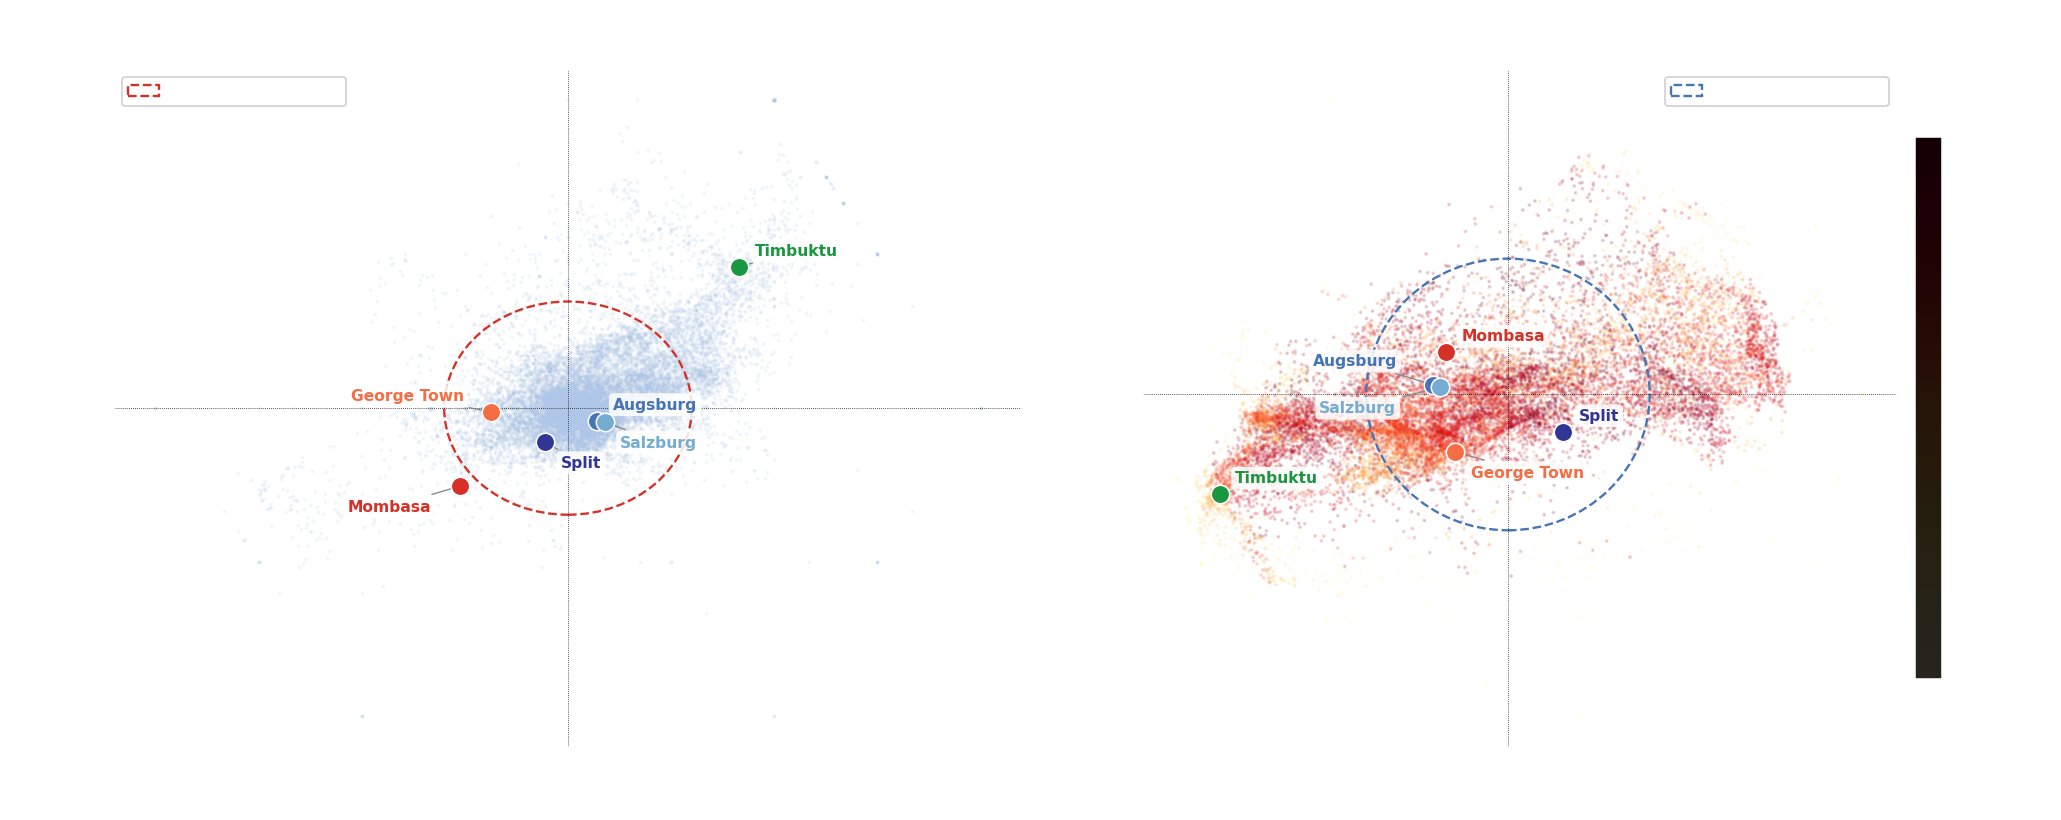

In [8]:
# Cell 6 — Part B: harmonic component scatter — visualise where probe cities sit
print("drawing harmonic component scatter...")

probe_colors = {
    'Mombasa':     '#d73027',
    'Augsburg':    '#4575b4',
    'Salzburg':    '#74add1',
    'George Town': '#f46d43',
    'Split':       '#313695',
    'Timbuktu':    '#1a9641',
}

# Per-city annotation offsets (points) tuned to avoid overlap in each panel
offsets_left = {           # (a2, b2) panel
    'Mombasa':     (-58, -13),
    'Augsburg':    (  8,   6),
    'Salzburg':    (  8, -13),
    'George Town': (-72,   6),
    'Split':       (  8, -13),
    'Timbuktu':    (  8,   6),
}
offsets_right = {          # (a1, b1) panel
    'Mombasa':     (  8,   6),
    'Augsburg':    (-62,  10),
    'Salzburg':    (-62, -13),
    'George Town': (  8, -13),
    'Split':       (  8,   6),
    'Timbuktu':    (  8,   6),
}
label_kw = dict(
    fontsize=8, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.85),
    arrowprops=dict(arrowstyle='-', color='#888888', lw=0.7),
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: semi-annual space (a2, b2) ──
ax = axes[0]
ax.scatter(df06['a2'], df06['b2'], s=1, alpha=0.12, c='#aec7e8', rasterized=True)
circle = plt.Circle((0, 0), 0.3, fill=False, color='#d73027', lw=1.2,
                    ls='--', label='R_dbl = 0.3 threshold')
ax.add_patch(circle)
for _, row in probes.iterrows():
    c = probe_colors[row['city']]
    ax.scatter(row['a2'], row['b2'], s=90, color=c, zorder=5,
               edgecolors='white', linewidths=0.8)
    ox, oy = offsets_left[row['city']]
    ax.annotate(row['city'], xy=(row['a2'], row['b2']),
                xytext=(ox, oy), textcoords='offset points', color=c, **label_kw)
ax.axhline(0, color='k', lw=0.4, ls=':')
ax.axvline(0, color='k', lw=0.4, ls=':')
ax.set_xlabel('a2  (semi-annual cosine component)')
ax.set_ylabel('b2  (semi-annual sine component)')
ax.set_title('Semi-annual harmonic (a2, b2)\nMombasa outside R_dbl=0.3; others inside')
ax.legend(fontsize=8, loc='upper left')

# ── Right: annual space (a1, b1) coloured by log10(annual total) ──
ax = axes[1]
sc = ax.scatter(df06['a1'], df06['b1'], s=1, alpha=0.15,
                c=np.log10(df06['pre_mm_syr'].clip(10)),
                cmap='YlOrRd', vmin=1.5, vmax=3.3, rasterized=True)
circle = plt.Circle((0, 0), 0.4, fill=False, color='#4575b4', lw=1.2,
                    ls='--', label='R_std = 0.4 threshold')
ax.add_patch(circle)
for _, row in probes.iterrows():
    c = probe_colors[row['city']]
    ax.scatter(row['a1'], row['b1'], s=90, color=c, zorder=5,
               edgecolors='white', linewidths=0.8)
    ox, oy = offsets_right[row['city']]
    ax.annotate(row['city'], xy=(row['a1'], row['b1']),
                xytext=(ox, oy), textcoords='offset points', color=c, **label_kw)
ax.axhline(0, color='k', lw=0.4, ls=':')
ax.axvline(0, color='k', lw=0.4, ls=':')
ax.set_xlabel('a1  (annual cosine component)')
ax.set_ylabel('b1  (annual sine component)')
ax.set_title('Annual harmonic (a1, b1)\ncolour = log₁₀(annual precip mm/yr)')
ax.legend(fontsize=8, loc='upper right')
cb = plt.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
cb.set_label('Annual precip (mm/yr)')
cb.set_ticks([1.5, 2.0, 2.5, 3.0, 3.3])
cb.set_ticklabels(['32', '100', '316', '1000', '2000+'])

fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')
fig.tight_layout()
out_path = OUT / 'wo2a_harmonic_scatter.png'
fig.savefig(out_path, facecolor='white', dpi=140, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(out_path)))

## Part C — Held-out validation

Expected bimodal set written **before computing** (work-order requirement).

These locations were chosen from published climatology of ITCZ double-passage and double-monsoon
regions. They were **not** among the probe cities used to calibrate WO2 thresholds.

| Label | Lat | Lon | Expected regime | Rationale |
|-------|-----|-----|-----------------|----------|
| Vietnam/Hanoi | 21.0 | 105.8 | bimodal | May and September peaks; ITCZ double-passage |
| Vietnam/HCM | 10.8 | 106.7 | bimodal | May and October peaks; distinct wet-dry-wet |
| Thailand/Bangkok | 13.7 | 100.5 | bimodal | May and September peaks |
| Philippines/Manila | 14.6 | 120.9 | bimodal | June and October peaks |
| Australia/Darwin | -12.5 | 130.8 | single or bimodal | Nov–Apr dominant; possible secondary; uncertain |
| India/Kerala-S | 8.5 | 76.9 | bimodal | June and October monsoon limbs |
| India/Kerala-N | 9.9 | 76.3 | bimodal | Same double-monsoon zone |
| WAfrica/Abidjan | 5.3 | -4.0 | bimodal | May and October peaks; Guinea coast break |
| WAfrica/Conakry | 9.5 | -13.7 | single | Single long rainy season; expect NOT bimodal |
| Mexico/Manzanillo | 19.1 | -104.3 | bimodal (weak) | Double ITCZ; uncertain amplitude |
| Mexico/Acapulco | 16.9 | -99.9 | bimodal (weak) | Pacific double-ITCZ zone |

Darwin and Conakry are **negative controls**: Darwin may classify single (one dominant wet season);
Conakry receives a single concentrated rainy season and should NOT cluster with Mombasa.

**Test criterion:** Under the continuous (a1,b1,a2,b2) representation, positive-expected cities
should be closer to Mombasa than to Augsburg. Negative controls should be closer to Augsburg
(or Timbuktu) than to Mombasa.

In [10]:
# Cell 8 — Part C: look up held-out basins
# ST_Contains fails for coastal/peninsula points (Manila, Darwin, Conakry fall in water).
# KNN nearest-basin query (<-> operator) is robust for any location.
# hybas_id::bigint avoids float representation from PostgreSQL.
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

held_out = [
    ('Vietnam/Hanoi',      21.0,  105.8, 'positive'),
    ('Vietnam/HCM',        10.8,  106.7, 'positive'),
    ('Thailand/Bangkok',   13.7,  100.5, 'positive'),
    ('Philippines/Manila', 14.6,  120.9, 'positive'),
    ('Australia/Darwin',  -12.5,  130.8, 'uncertain'),
    ('India/Kerala-S',      8.5,   76.9, 'positive'),
    ('India/Kerala-N',      9.9,   76.3, 'positive'),
    ('WAfrica/Abidjan',     5.3,   -4.0, 'positive'),
    ('WAfrica/Conakry',     9.5,  -13.7, 'negative'),
    ('Mexico/Manzanillo',  19.1, -104.3, 'positive'),
    ('Mexico/Acapulco',    16.9,  -99.9, 'positive'),
]

rows = []
for label, lat, lon, expected in held_out:
    sql = f"""
    SELECT hybas_id::bigint AS hybas_id, pre_mm_syr,
           pre_mm_s01, pre_mm_s02, pre_mm_s03, pre_mm_s04,
           pre_mm_s05, pre_mm_s06, pre_mm_s07, pre_mm_s08,
           pre_mm_s09, pre_mm_s10, pre_mm_s11, pre_mm_s12
    FROM basin06
    ORDER BY geom <-> ST_SetSRID(ST_MakePoint({lon}, {lat}), 4326)
    LIMIT 1
    """
    row = pd.read_sql(sql, conn)
    row['label'] = label
    row['expected'] = expected
    rows.append(row)

held_df = pd.concat(rows, ignore_index=True)
print(f"Found {len(held_df)} of {len(held_out)} held-out locations\n")
print(held_df[['label', 'expected', 'hybas_id', 'pre_mm_syr']].to_string())

Found 11 of 11 held-out locations

                 label   expected    hybas_id  pre_mm_syr
0        Vietnam/Hanoi   positive  4060015010        1730
1          Vietnam/HCM   positive  4060016810        2131
2     Thailand/Bangkok   positive  4060018280        1408
3   Philippines/Manila   positive  5060028890        2345
4     Australia/Darwin  uncertain  5060062210        1539
5       India/Kerala-S   positive  4060029530        2414
6       India/Kerala-N   positive  4060029530        2414
7      WAfrica/Abidjan   positive  1060023900        1461
8      WAfrica/Conakry   negative  1060025460        2838
9    Mexico/Manzanillo   positive  7060005810        1208
10     Mexico/Acapulco   positive  7060005000        1357


In [11]:
# Cell 9 — Part C: compute continuous features + distances for held-out set
Ph = held_df[month_cols].values.astype(float)
th = Ph.sum(axis=1)
with np.errstate(invalid='ignore', divide='ignore'):
    held_df['a1'] = np.where(th > 0, (Ph * np.cos(theta1)).sum(axis=1) / th, np.nan)
    held_df['b1'] = np.where(th > 0, (Ph * np.sin(theta1)).sum(axis=1) / th, np.nan)
    held_df['a2'] = np.where(th > 0, (Ph * np.cos(theta2)).sum(axis=1) / th, np.nan)
    held_df['b2'] = np.where(th > 0, (Ph * np.sin(theta2)).sum(axis=1) / th, np.nan)
held_df['R_std'] = np.sqrt(held_df['a1']**2 + held_df['b1']**2)
held_df['R_dbl'] = np.sqrt(held_df['a2']**2 + held_df['b2']**2)

# Reference probes
mombasa  = probes[probes['city'] == 'Mombasa'].iloc[0]
augsburg = probes[probes['city'] == 'Augsburg'].iloc[0]
timbuktu = probes[probes['city'] == 'Timbuktu'].iloc[0]

def feat(row):
    return np.array([row['a1'], row['b1'], row['a2'], row['b2']])

fm = feat(mombasa); fa = feat(augsburg); ft = feat(timbuktu)

held_df['dist_mombasa']  = held_df.apply(lambda r: np.sqrt(((feat(r) - fm)**2).sum()), axis=1)
held_df['dist_augsburg'] = held_df.apply(lambda r: np.sqrt(((feat(r) - fa)**2).sum()), axis=1)
held_df['dist_timbuktu'] = held_df.apply(lambda r: np.sqrt(((feat(r) - ft)**2).sum()), axis=1)
held_df['closer_to'] = np.where(
    held_df['dist_mombasa'] < held_df['dist_augsburg'], 'Mombasa', 'Augsburg')

display_cols = ['label', 'expected', 'pre_mm_syr', 'R_std', 'R_dbl',
                'dist_mombasa', 'dist_augsburg', 'closer_to']
print(held_df[display_cols].sort_values('dist_mombasa').to_string())

                 label   expected  pre_mm_syr     R_std     R_dbl  dist_mombasa  dist_augsburg closer_to
7      WAfrica/Abidjan   positive        1461  0.325115  0.246408      0.177612       0.303376   Mombasa
5       India/Kerala-S   positive        2414  0.439790  0.136539      0.444123       0.267435  Augsburg
6       India/Kerala-N   positive        2414  0.439790  0.136539      0.444123       0.267435  Augsburg
1          Vietnam/HCM   positive        2131  0.496251  0.068121      0.524514       0.357718  Augsburg
3   Philippines/Manila   positive        2345  0.355306  0.073316      0.536541       0.310618  Augsburg
2     Thailand/Bangkok   positive        1408  0.501748  0.180748      0.553693       0.429742  Augsburg
0        Vietnam/Hanoi   positive        1730  0.552369  0.137289      0.646753       0.404521  Augsburg
10     Mexico/Acapulco   positive        1357  0.698820  0.228725      0.842647       0.579059  Augsburg
8      WAfrica/Conakry   negative        2838  0.699760

In [12]:
# Cell 10 — Part D: continuous precip-temperature phase relation for probe cities
#
# Replace the scalar seas_phase_offset with (cross, dot) — the vector product of the
# precip and temperature annual harmonic vectors. These are wraparound-free and degrade
# gracefully: weak cycles produce small values rather than arbitrary angles.
#
#   cross = a1_p * tb1 - b1_p * ta1    (sin of phase diff × product of amplitudes)
#   dot   = a1_p * ta1 + b1_p * tb1    (cos of phase diff × product of amplitudes)
#
# When both cycles are strong and in-phase:  dot large positive, cross near zero.
# When both strong and anti-phase (e.g. summer rain + summer heat): dot large positive again
#   but that's because both point the same direction — the cross encodes the signed
#   deviation from perfect alignment.
# When either cycle is weak: both shrink; the basin clusters with other weak-cycle basins.
#
# NOTE: (ta1, tb1) are NOT normalized here — amplitude is carried into (cross, dot),
# so weak-temperature basins (equatorial) naturally cluster together.

probes['cross'] = probes['a1'] * probes['tb1'] - probes['b1'] * probes['ta1']
probes['dot']   = probes['a1'] * probes['ta1'] + probes['b1'] * probes['tb1']

# For comparison: old seas_phase_offset from arctan2 (carries the bimodal contamination)
probes['phi_precip'] = (np.degrees(np.arctan2(probes['b1'], probes['a1'])) % 360) / 30
probes['phi_temp']   = (np.degrees(np.arctan2(probes['tb1'], probes['ta1'])) % 360) / 30
probes['seas_phase_old'] = (probes['phi_precip'] - probes['phi_temp']) % 12

print("Part D — Continuous precip-temp phase relation vs. scalar seas_phase_offset\n")
cols = ['city', 'T_mean', 'T_amp', 'cross', 'dot', 'seas_phase_old']
print(probes[cols].to_string())
print()
print("Interpretation:")
print("  cross > 0: precip leads temperature (e.g. spring rains before summer heat)")
print("  dot > 0:   precip and temperature harmonics point in similar half-plane")
print("  Both near 0: either cycle is very weak (equatorial temperature, hyper-arid precip)")

Part D — Continuous precip-temp phase relation vs. scalar seas_phase_offset

          city     T_mean     T_amp     cross       dot  seas_phase_old
0     Augsburg   7.400000  9.143963  0.394874  1.902155       11.609079
1  George Town  26.925000  0.550655 -0.088169 -0.086959        4.486811
2      Mombasa  25.383333  1.869260 -0.339068 -0.215687        4.082038
3     Salzburg   7.916667  9.770869  0.247289  1.873904       11.749414
4        Split  13.900000  8.956846 -1.204538 -1.210861        4.505000
5     Timbuktu  28.225000  5.670563 -2.491427  4.228256        1.016933

Interpretation:
  cross > 0: precip leads temperature (e.g. spring rains before summer heat)
  dot > 0:   precip and temperature harmonics point in similar half-plane
  Both near 0: either cycle is very weak (equatorial temperature, hyper-arid precip)


In [13]:
# Cell 11 — Part D: check Mediterranean contamination path is closed
#
# WO2 A7 showed that seas_phase_offset for Mombasa (~4.08) falls within the range of
# Mediterranean cities (~5-6), causing Split, Ibiza, and Vatican City to appear as
# Mombasa's nearest neighbours in the phase lens.
# Split is the Mediterranean exemplar (coastal Dalmatian, clean signal at L08).
# Test: does (cross, dot) separate Split from Mombasa where seas_phase_offset did not?

phase_probes = probes[probes['city'].isin(
    ['Mombasa', 'Split', 'Augsburg', 'George Town', 'Timbuktu'])].copy()

# Distance in continuous (cross, dot) space
m_cross = phase_probes.loc[phase_probes['city'] == 'Mombasa', 'cross'].values[0]
m_dot   = phase_probes.loc[phase_probes['city'] == 'Mombasa', 'dot'].values[0]
phase_probes['dist_phase_cts'] = np.sqrt(
    (phase_probes['cross'] - m_cross)**2 + (phase_probes['dot'] - m_dot)**2)

# Distance in old seas_phase_offset space (circular, period 12)
m_spo = phase_probes.loc[phase_probes['city'] == 'Mombasa', 'seas_phase_old'].values[0]
phase_probes['dist_phase_old'] = np.abs(
    (phase_probes['seas_phase_old'] - m_spo + 6) % 12 - 6)

print("Distance from Mombasa — continuous (cross,dot) vs. scalar seas_phase_offset\n")
print(phase_probes[['city', 'cross', 'dot', 'seas_phase_old',
                     'dist_phase_cts', 'dist_phase_old']].to_string())
print()
print("Contamination closed if Split's dist_phase_cts >> Augsburg's dist_phase_cts")
print("(i.e. in continuous phase space, Augsburg is closer to Mombasa than Split is)")

Distance from Mombasa — continuous (cross,dot) vs. scalar seas_phase_offset

          city     cross       dot  seas_phase_old  dist_phase_cts  dist_phase_old
0     Augsburg  0.394874  1.902155       11.609079        2.241411        4.472959
1  George Town -0.088169 -0.086959        4.486811        0.281994        0.404773
2      Mombasa -0.339068 -0.215687        4.082038        0.000000        0.000000
4        Split -1.204538 -1.210861        4.505000        1.318867        0.422962
5     Timbuktu -2.491427  4.228256        1.016933        4.937740        3.065105

Contamination closed if Split's dist_phase_cts >> Augsburg's dist_phase_cts
(i.e. in continuous phase space, Augsburg is closer to Mombasa than Split is)


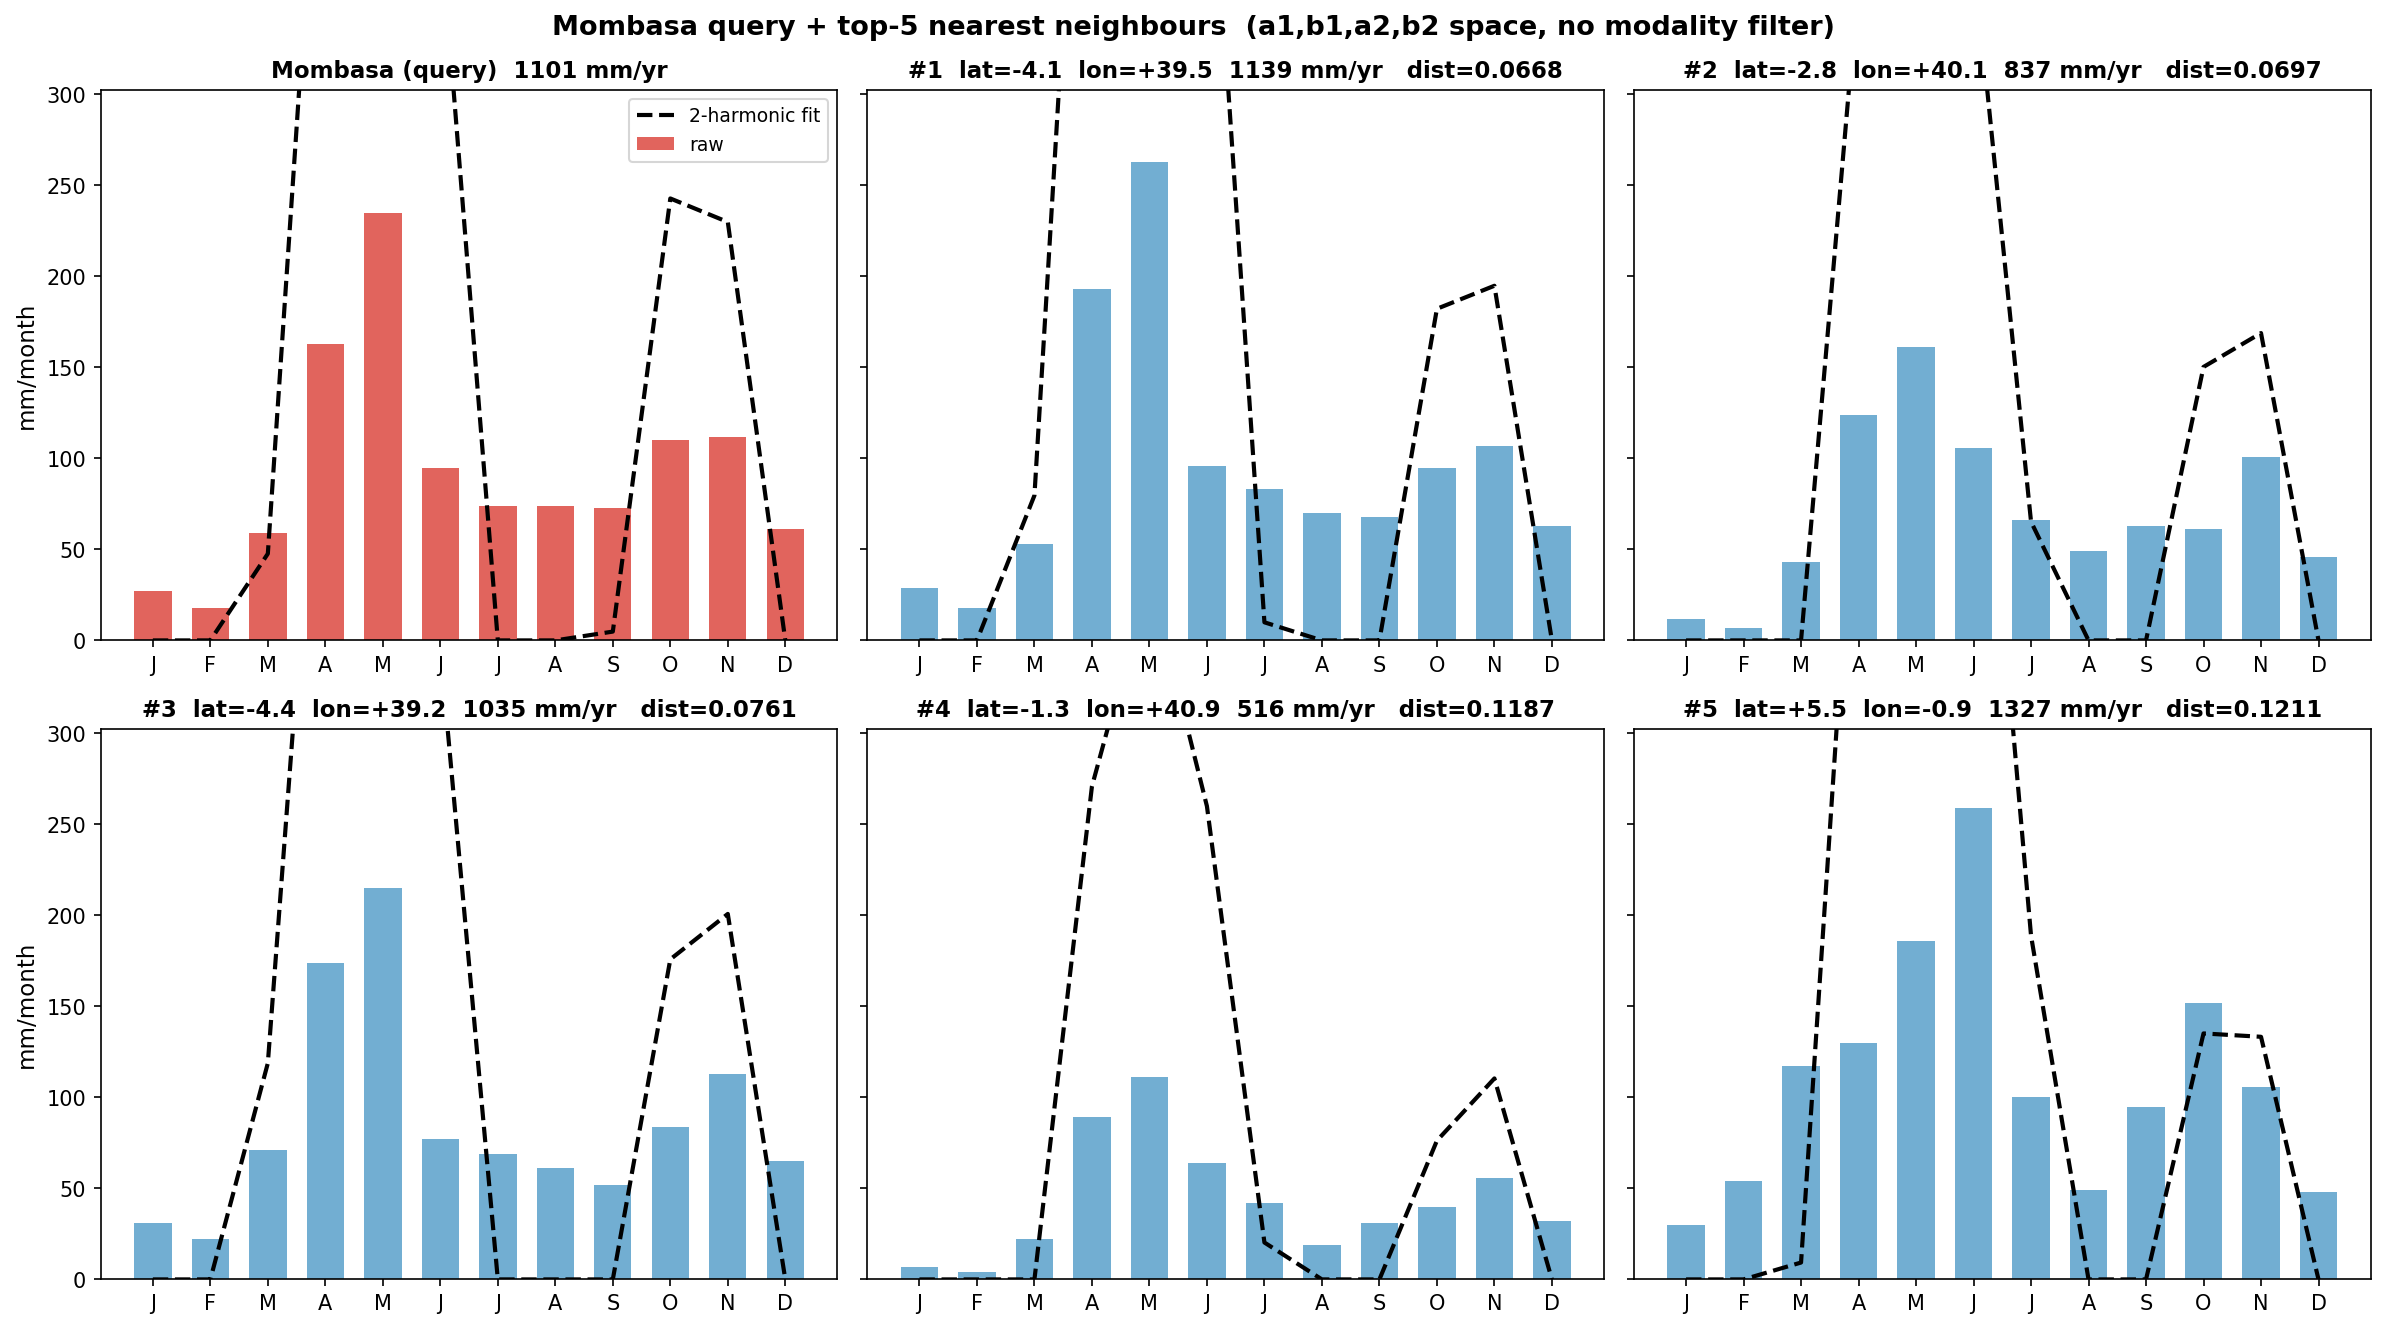

In [16]:
# Cell 12 — Part E: monthly profile small multiples for Mombasa's nearest neighbours
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

mombasa_row = probes[probes['city'] == 'Mombasa'].iloc[0]
mfeat = np.array([mombasa_row['a1'], mombasa_row['b1'],
                  mombasa_row['a2'], mombasa_row['b2']])

dists_m = np.sqrt(((F06_valid - mfeat)**2).sum(axis=1))
top5_idx = np.argsort(dists_m)[1:6]
top5_ids  = hybas_valid[top5_idx]
top5_dist = dists_m[top5_idx]

id_list = ','.join(str(i) for i in top5_ids)
nbr_sql = f"""
SELECT hybas_id, pre_mm_syr,
       pre_mm_s01, pre_mm_s02, pre_mm_s03, pre_mm_s04,
       pre_mm_s05, pre_mm_s06, pre_mm_s07, pre_mm_s08,
       pre_mm_s09, pre_mm_s10, pre_mm_s11, pre_mm_s12,
       ST_Y(ST_Centroid(geom)) AS lat,
       ST_X(ST_Centroid(geom)) AS lon
FROM basin06 WHERE hybas_id IN ({id_list})
"""
nbrs = pd.read_sql(nbr_sql, conn)
nbrs = nbrs.set_index('hybas_id').loc[top5_ids].reset_index()

def two_harmonic_fit(vals):
    total = vals.sum()
    if total == 0:
        return np.zeros(12)
    _a1 = (vals * np.cos(theta1)).sum() / total
    _b1 = (vals * np.sin(theta1)).sum() / total
    _a2 = (vals * np.cos(theta2)).sum() / total
    _b2 = (vals * np.sin(theta2)).sum() / total
    mean = total / 12
    return (mean + total * (_a1*np.cos(theta1) + _b1*np.sin(theta1)
                          + _a2*np.cos(theta2) + _b2*np.sin(theta2))).clip(0)

mombasa_precip = mombasa_row[month_cols].values.astype(float)
all_vals = np.concatenate([mombasa_precip] +
                          [nbrs.loc[i, month_cols].values.astype(float) for i in range(len(nbrs))])
ymax = all_vals.max() * 1.15
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
x = np.arange(12)

print("drawing monthly profile small multiples...")
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
fig.patch.set_facecolor('white')
fig.suptitle("Mombasa query + top-5 nearest neighbours  (a1,b1,a2,b2 space, no modality filter)",
             fontsize=13, fontweight='bold', color='black')

def draw_profile(ax, vals, title, color, dist=None):
    fit = two_harmonic_fit(vals)
    ax.bar(x, vals, color=color, width=0.65, alpha=0.75, label='raw')
    ax.plot(x, fit, color='black', lw=2.0, ls='--', label='2-harmonic fit')
    label = title if dist is None else f"{title}   dist={dist:.4f}"
    ax.set_title(label, fontsize=11, fontweight='bold', color='black', pad=6)
    ax.set_xticks(x)
    ax.set_xticklabels(month_labels, fontsize=10, color='black')
    ax.tick_params(axis='y', labelsize=10, colors='black')
    ax.tick_params(axis='x', colors='black')
    ax.set_ylim(0, ymax)
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')

draw_profile(axes[0, 0], mombasa_precip, 'Mombasa (query)  1101 mm/yr', '#d73027')
axes[0, 0].set_ylabel('mm/month', fontsize=11, color='black')
leg = axes[0, 0].legend(fontsize=9)
for text in leg.get_texts():
    text.set_color('black')

for i, (_, nbr_row) in enumerate(nbrs.iterrows()):
    ax = axes.flat[i + 1]
    vals = nbr_row[month_cols].values.astype(float)
    title = (f"#{i+1}  lat={nbr_row['lat']:+.1f}  lon={nbr_row['lon']:+.1f}"
             f"  {int(nbr_row['pre_mm_syr'])} mm/yr")
    draw_profile(ax, vals, title, '#4393c3', dist=top5_dist[i])
    if i == 2:
        ax.set_ylabel('mm/month', fontsize=11, color='black')

fig.tight_layout()
out_path = OUT / 'wo2a_mombasa_profiles.png'
fig.savefig(out_path, facecolor='white', dpi=150, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(out_path)))

In [18]:
# Cell 13 — Part C follow-up: Bangkok, HCM, Manila own top-5 neighbours
#
# Opus objection: "closer to Mombasa or Augsburg" is a two-anchor forced choice.
# Bangkok is honestly neither. The right test is what Bangkok's OWN top-5 look like.
# If they are other SE Asian monsoon basins the representation is working correctly and
# the held-out design was simply the wrong instrument.
#
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

check_cities = ['Thailand/Bangkok', 'Vietnam/HCM', 'Philippines/Manila']
check_df = held_df[held_df['label'].isin(check_cities)].copy().reset_index(drop=True)

# Reorder to match figure left-to-right
check_df = check_df.set_index('label').loc[['Vietnam/HCM', 'Thailand/Bangkok', 'Philippines/Manila']].reset_index()

# For each city: find its own top-5 in (a1,b1,a2,b2) space
city_nn = {}
for _, row in check_df.iterrows():
    q = np.array([row['a1'], row['b1'], row['a2'], row['b2']])
    dists = np.sqrt(((F06_valid - q)**2).sum(axis=1))
    top_idx = np.argsort(dists)[:6]
    top_idx = [i for i in top_idx if dists[i] > 1e-6][:5]
    city_nn[row['label']] = {
        'hybas_ids': hybas_valid[top_idx].tolist(),
        'dists':     dists[top_idx].tolist(),
    }

all_nn_ids = list({h for r in city_nn.values() for h in r['hybas_ids']})
id_list = ','.join(str(i) for i in all_nn_ids)
cents2 = pd.read_sql(f"""
    SELECT hybas_id, ST_X(ST_Centroid(geom)) AS lon, ST_Y(ST_Centroid(geom)) AS lat
    FROM basin06 WHERE hybas_id IN ({id_list})
""", conn).set_index('hybas_id')

# ── Figure first; text output after (PyCharm overwrites text with figure) ──
print("drawing Bangkok / HCM / Manila monthly profiles...")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('white')
fig.suptitle("Bangkok, HCM, Manila — monthly precip + two-harmonic fit",
             fontsize=12, fontweight='bold', color='black')

for ax, (_, row) in zip(axes, check_df.iterrows()):
    vals = row[month_cols].values.astype(float)
    fit  = two_harmonic_fit(vals)
    ax.bar(x, vals, color='#6baed6', width=0.65, alpha=0.80, label='raw')
    ax.plot(x, fit, color='black', lw=2.0, ls='--', label='2-harmonic fit')
    ax.set_title(f"{row['label']}\n{int(row['pre_mm_syr'])} mm/yr  "
                 f"R_std={row['R_std']:.3f}  R_dbl={row['R_dbl']:.3f}",
                 fontsize=10, fontweight='bold', color='black')
    ax.set_xticks(x)
    ax.set_xticklabels(month_labels, fontsize=9, color='black')
    ax.tick_params(colors='black')
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
    ax.set_ylabel('mm/month', fontsize=10, color='black')

axes[0].legend(fontsize=9)
for text in axes[0].legend().get_texts():
    text.set_color('black')

fig.tight_layout()
out_path = OUT / 'wo2a_bangkok_check.png'
fig.savefig(out_path, facecolor='white', dpi=150, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(out_path)))

# ── Top-5 neighbours printed after figure so PyCharm doesn't swallow them ──
print("\nPart C follow-up — own top-5 neighbours\n")
for city, r in city_nn.items():
    row = check_df[check_df['label'] == city].iloc[0]
    print(f"  {city}  (R_std={row['R_std']:.3f}, R_dbl={row['R_dbl']:.3f}, {int(row['pre_mm_syr'])} mm/yr)")
    for hid, d in zip(r['hybas_ids'], r['dists']):
        lat = cents2.loc[hid, 'lat'];  lon = cents2.loc[hid, 'lon']
        print(f"    hybas={int(hid)}  dist={d:.4f}  lat={lat:+6.1f}  lon={lon:+7.1f}")
    print()


Part C follow-up — own top-5 neighbours

  Vietnam/HCM  (R_std=0.496, R_dbl=0.068, 2131 mm/yr)
    hybas=7060003300  dist=0.0382  lat= +14.5  lon=  -91.4
    hybas=4061140110  dist=0.0509  lat= +12.4  lon= +104.1
    hybas=4061062700  dist=0.0512  lat= +19.3  lon=  +97.9
    hybas=1060025000  dist=0.0565  lat=  +8.4  lon=  -10.5
    hybas=1060024780  dist=0.0581  lat=  +6.1  lon=  -10.1

  Thailand/Bangkok  (R_std=0.502, R_dbl=0.181, 1408 mm/yr)
    hybas=4060018330  dist=0.0326  lat= +14.4  lon=  +99.9
    hybas=4060018240  dist=0.0398  lat= +13.6  lon= +100.8
    hybas=4060018290  dist=0.0563  lat= +13.6  lon= +100.4
    hybas=4061104190  dist=0.0644  lat= +18.0  lon=  +99.0
    hybas=4061109830  dist=0.0678  lat= +15.2  lon=  +75.9

  Philippines/Manila  (R_std=0.355, R_dbl=0.073, 2345 mm/yr)
    hybas=5060027490  dist=0.0553  lat= +10.0  lon= +123.0
    hybas=5060027960  dist=0.0624  lat= +11.2  lon= +122.5
    hybas=7060883030  dist=0.0662  lat= +10.4  lon=  -84.5
    hybas=50600